# Getting Started with *mibitrans*

Simple hydrogeological contaminant transport modelling with the *mibitrans* package.

**Authors:** Alraune Zech, Jorrit Bakker

**Todo:** Comment individual parts

In [1]:
import matplotlib.pyplot as plt
import mibitrans as mbt

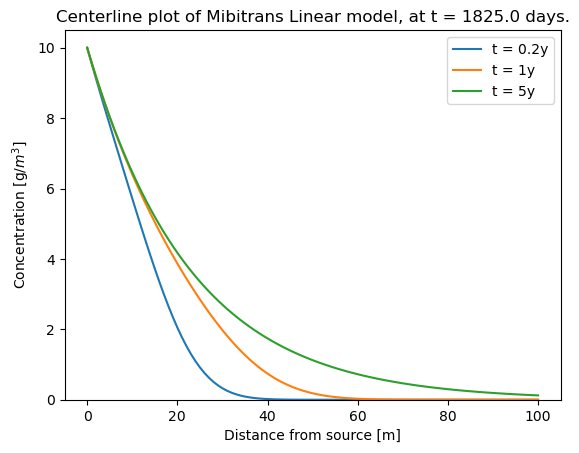

In [2]:
hydro = mbt.HydrologicalParameters(velocity = 0.1, 
                                   porosity = 0.3,
                                   alpha_x = 3, 
                                   alpha_y = 0.02,
                                   alpha_z = 0.005)
attenuation = mbt.AttenuationParameters(retardation = 1.3, 
                                        half_life = 0.5*365)
source = mbt.SourceParameters(source_zone_boundary = [5, 10, 20], 
                              source_zone_concentration = [10, 4, 0.5],
                              depth = 2)
model = mbt.ModelParameters(model_length = 100,
                            model_width = 60,
                            model_time = 5 * 365)
mbt_object = mbt.Mibitrans(hydro,attenuation,source,model)
mbt_results = mbt_object.run()
mbt_results.centerline(time = 0.2*365, label ='t = 0.2y')
mbt_results.centerline(time = 1*365, label ='t = 1y')
mbt_results.centerline(label = 't = 5y')
plt.legend()
plt.show()

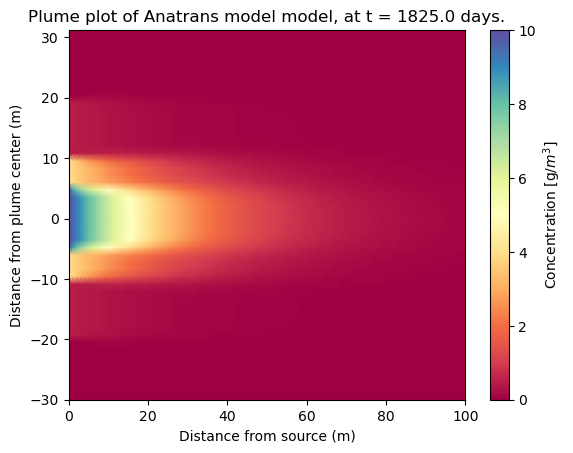

In [3]:
ana_object = mbt.Anatrans(hydro, attenuation, source, model)
ana_results = ana_object.run()
ana_results.plume_2d(cmap="Spectral", shading="gouraud")

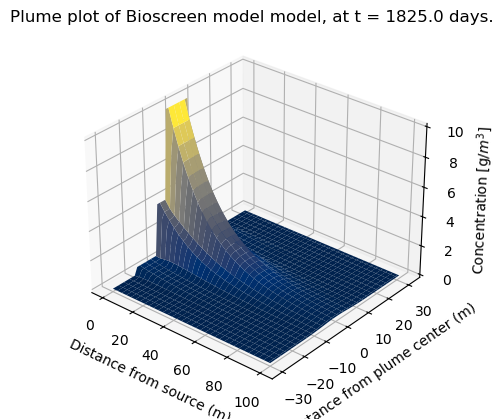

In [4]:
bio_object = mbt.Bioscreen(hydro,attenuation,source,model)
bio_results = bio_object.run()
ax = bio_results.plume_3d(cmap="cividis")

In [5]:
mbt_object.attenuation_parameters.decay_rate = 0 
mbt_results_nd = mbt_object.run()

In [6]:
mbt_object_inst = mbt.Mibitrans(hydro,attenuation,
                                source,model)
mbt_object_inst.instant_reaction(
    electron_acceptors={"delta_oxygen":9,
    "delta_nitrate":6,"ferrous_iron":8,
    "delta_sulfate":5,"methane":4})
mbt_results_inst = mbt_object_inst.run()

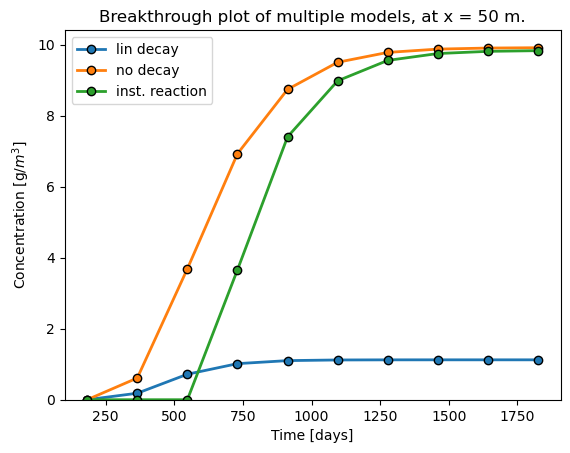

In [7]:
mbt.breakthrough([mbt_results,mbt_results_nd,mbt_results_inst],
                 x_position=50,lw = 2, marker = 'o',mec = 'k')
plt.legend(['lin decay','no decay','inst. reaction'])